# Credit Scoring ML Project

## Project goal
The goal of this project is to build a machine learning model for credit risk prediction based on historical client data.

## What is done in this notebook:
- Data loading and inspection
- Feature engineering from raw transactional data
- Aggregation to client-level features
- Model training and evaluation

## Key ideas:
- Work with large datasets using chunk processing
- Memory optimization (downcasting types)
- Feature engineering from payment history

## Tech stack

- Python
- pandas, numpy
- scikit-learn
- LightGBM
- Optuna
- matplotlib
- joblib

## Runtime note

This notebook was originally run in Google Colab because the dataset is large and my local machine does not have enough RAM.

For GitHub, I changed all file paths to relative project paths:

- `data/raw/`
- `data/processed/`
- `models/`

The full dataset is not uploaded to GitHub because of its size.  
To run the project, place the data files into the `data/raw/` folder.

A cleaner production-style version of the code is moved to Python scripts in the `src/` folder.

## Feature Engineering

Unnecessary features are those that can cause data leakage or repeat the same information.

In this step, I create preprocessing that I apply to each data chunk.  
First, I change data types to smaller ones to save memory,  
because the dataset is large and may not fit into RAM.


In [5]:
import pandas as pd
from pandas.api.types import is_integer_dtype
from pandas.api.types import is_float_dtype
import gc


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:

    for c in df.select_dtypes(include=['int64', 'int32']).columns:
        df[c] = pd.to_numeric(df[c], downcast='integer')

    paym_cols = [c for c in df.columns if c.startswith('enc_paym_')]

    # Mode of payment statuses over the whole history.
    # This feature shows the most frequent (mode) value of payment statuses for each credit.
    # It helps the model see not only monthly behavior but overall payment pattern.
    df['enc_mode'] = df[paym_cols].mode(axis=1, dropna=True).iloc[:, 0].fillna(-1).astype('Int8')
    gc.collect()

    # Count of problematic payments over the whole history.
    # We assume that status 0 = normal, others = overdue.
    # If there is at least one overdue payment, the risk is higher.
    df['bad_pay_count'] = (df[paym_cols] > 0).sum(axis=1).astype('Int8')
    gc.collect()

    # Variance of payment statuses.
    # This shows how stable or unstable the client is.
    # Low variance = more stable behavior, which is usually better.
    df['paym_status_variance'] = df[paym_cols].var(axis=1).fillna(0).astype('float32')
    gc.collect()

    stayed_columns = [
        'id', 'rn', 'pre_since_opened', 'pre_since_confirmed', 'pre_pterm',
        'pre_till_pclose', 'pre_loans_credit_limit', 'pre_loans_next_pay_summ',
        'pre_loans_outstanding', 'pre_loans_max_overdue_sum',
        'pre_loans_credit_cost_rate', 'is_zero_loans5', 'is_zero_loans530',
        'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90', 'pre_util',
        'pre_over2limit', 'pre_maxover2limit', 'is_zero_util', 'is_zero_maxover2limit',
        'enc_loans_credit_status', 'enc_loans_account_cur',
        'enc_loans_credit_type', 'pclose_flag', 'enc_paym_0', 'enc_paym_5',
        'enc_paym_8', 'enc_paym_11', 'enc_mode', 'bad_pay_count', 'paym_status_variance'
    ]

    for c in df.select_dtypes(include=['int64', 'int32']).columns:
        df[c] = pd.to_numeric(df[c], downcast='integer')

    gc.collect()

    return df[stayed_columns]

## Data Loading

The original dataset is stored as several parquet files inside a zip archive.  
I extract the archive and then process the data in chunks, because the dataset is too large to load everything at once.



In [6]:
import os

if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")

In [69]:
import os
import zipfile

zip_path = "data/raw/train_data.zip"
extract_folder = "data/raw/train_data"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as archive:
    archive.extractall(extract_folder)

print("Archive files:")
print(os.listdir(extract_folder))

Archive files:
['__MACOSX', 'train_data']


Here I process the dataset in chunks.

For each chunk, I apply the preprocessing function and add the result to one merged dataset.

This helps me work with a large dataset without using too much RAM.

After each step, I delete temporary variables and clear memory.

In [8]:
import gc
import pandas as pd

processed_chunks = []

for i in range(12):
    print(f"Chunk {i} is processing...")

    chunk = pd.read_parquet(f"data/raw/train_data/train_data/train_data_{i}.pq")

    chunk_prepared = preprocess_data(chunk)
    processed_chunks.append(chunk_prepared)

    del chunk, chunk_prepared
    gc.collect()

df = pd.concat(processed_chunks, ignore_index=True)
df = df.sort_values(by="id").reset_index(drop=True)

del processed_chunks
gc.collect()

Chunk 0 is processing...
Chunk 1 is processing...
Chunk 2 is processing...
Chunk 3 is processing...
Chunk 4 is processing...
Chunk 5 is processing...
Chunk 6 is processing...
Chunk 7 is processing...
Chunk 8 is processing...
Chunk 9 is processing...
Chunk 10 is processing...
Chunk 11 is processing...


0

In [9]:
import os

# Save processed dataset
os.makedirs("data/processed", exist_ok=True)

output_path = "data/processed/full_df_processed.pq"

df.to_parquet(output_path)
df.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_max_overdue_sum,...,enc_loans_account_cur,enc_loans_credit_type,pclose_flag,enc_paym_0,enc_paym_5,enc_paym_8,enc_paym_11,enc_mode,bad_pay_count,paym_status_variance
0,0,1,18,9,2,16,11,3,3,2,...,1,4,0,0,3,3,4,3,23,0.86
1,0,10,7,9,2,8,16,4,2,2,...,1,4,0,0,0,3,4,3,19,2.00
2,0,8,2,9,2,12,15,5,3,2,...,1,4,0,0,3,3,4,3,23,0.86
3,0,7,3,9,1,12,15,5,3,2,...,1,4,0,0,0,3,4,3,17,2.39
4,0,6,5,0,11,12,4,2,3,2,...,1,3,0,0,0,0,1,0,7,2.14


In [10]:
df.shape

(26162717, 32)

## Load Target and Check Class Distribution

In [11]:
import pandas as pd

targets = pd.read_csv("data/raw/train_target.csv")

# Check target distribution.
# The dataset is imbalanced: class 1 is much smaller than class 0.
targets["flag"].value_counts()

flag
0    2893558
1     106442
Name: count, dtype: int64

## Join Features with Target

In [12]:
full_df_processed = pd.read_parquet('data/processed/full_df_processed.pq')
targets = pd.read_csv('data/raw/train_target.csv')

# Join features with target by id
df_merged = full_df_processed.merge(targets, on='id', how='left')

print(df_merged["flag"].isna().sum())


0


In [13]:
display(df_merged.head())
df_merged.shape

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_max_overdue_sum,...,enc_loans_credit_type,pclose_flag,enc_paym_0,enc_paym_5,enc_paym_8,enc_paym_11,enc_mode,bad_pay_count,paym_status_variance,flag
0,0,1,18,9,2,16,11,3,3,2,...,4,0,0,3,3,4,3,23,0.86,0
1,0,10,7,9,2,8,16,4,2,2,...,4,0,0,0,3,4,3,19,2.00,0
2,0,8,2,9,2,12,15,5,3,2,...,4,0,0,3,3,4,3,23,0.86,0
3,0,7,3,9,1,12,15,5,3,2,...,4,0,0,0,3,4,3,17,2.39,0
4,0,6,5,0,11,12,4,2,3,2,...,3,0,0,0,0,1,0,7,2.14,0


(26162717, 33)

In [14]:
# Save merged dataset
df_merged.to_parquet('data/processed/df_merged.parquet', index=False)

##Group dataset



In [15]:
# Sort data by client id and rn before grouping

df_merged_path = 'data/processed/df_merged.parquet'

df_merged = pd.read_parquet(df_merged_path).sort_values(by=['id', 'rn']).reset_index(drop=True)
df_merged.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_max_overdue_sum,...,enc_loans_credit_type,pclose_flag,enc_paym_0,enc_paym_5,enc_paym_8,enc_paym_11,enc_mode,bad_pay_count,paym_status_variance,flag
0,0,1,18,9,2,16,11,3,3,2,...,4,0,0,3,3,4,3,23,0.86,0
1,0,2,18,9,14,12,0,3,3,2,...,4,0,0,0,0,1,0,3,0.69,0
2,0,3,18,9,4,1,11,0,5,2,...,3,1,0,0,0,1,0,3,0.69,0
3,0,4,4,1,9,16,12,2,3,2,...,1,0,1,0,0,1,3,15,2.46,0
4,0,5,5,12,15,11,10,2,3,2,...,4,0,0,0,3,4,3,18,2.21,0


For each client, I keep the last record after sorting by 'id' and 'rn'.

This gives one final row per client before model training.

In [16]:
df_last_state = df_merged.drop_duplicates(subset='id', keep='last').copy().reset_index(drop=True)
df_last_state.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_max_overdue_sum,...,enc_loans_credit_type,pclose_flag,enc_paym_0,enc_paym_5,enc_paym_8,enc_paym_11,enc_mode,bad_pay_count,paym_status_variance,flag
0,0,10,7,9,2,8,16,4,2,2,...,4,0,0,0,3,4,3,19,2.00,0
1,1,14,12,6,1,14,11,2,3,2,...,3,0,3,3,3,4,3,25,0.11,0
2,2,3,12,9,4,1,1,1,4,2,...,3,1,3,3,3,4,3,25,0.11,0
3,3,15,12,9,2,8,17,1,2,2,...,4,0,0,3,3,4,3,24,0.50,0
4,4,1,12,9,4,1,12,1,3,2,...,3,1,3,3,3,4,3,25,0.11,0


In [17]:
print('Number of records after keeping last rn:')
df_last_state.shape

Number of records after keeping last rn:


(3000000, 33)

##Preparing data for model trainig



In [18]:
# Rename columns to make features more clear

df_last_state.columns = [
    'count_credit' if c == 'rn' else (c if c == 'id' or c == 'flag' else c + '_last')
    for c in df_last_state.columns
]

In [19]:
# Create new features by grouping client records

def get_mode(series):
    return series.mode().iloc[0] if not series.empty else -1

agg = {
    'pre_since_opened': ['median', 'max'],
    'pre_since_confirmed': 'median',
    'pre_pterm': ['median', 'max'],
    'pre_till_pclose': ['median', 'max'],
    'pre_loans_credit_limit': ['median', 'max'],
    'pre_loans_next_pay_summ':'median',
    'pre_loans_outstanding': ['median', 'max'],
    'pre_loans_max_overdue_sum': 'median',
    'pre_loans_credit_cost_rate': ['median', 'max'],
    'is_zero_loans5': ['min', 'mean'],
    'is_zero_loans530': ['min', 'mean'],
    'is_zero_loans3060': 'min',
    'is_zero_loans6090': 'min',
    'is_zero_loans90': 'mean',
    'pre_util': ['median', 'max'],
    'pre_over2limit': 'max',
    'pre_maxover2limit': 'median',
    'is_zero_util': 'mean',
    'is_zero_maxover2limit': ['min', 'mean'],
    'enc_loans_credit_status': get_mode,
    'enc_loans_credit_type': get_mode,
    'pclose_flag': 'mean',
    'enc_paym_5': get_mode,
    'enc_mode': get_mode,
    'enc_paym_8': get_mode,
    'enc_paym_11': get_mode,
    'bad_pay_count': ['sum', 'min', 'max'],
    'paym_status_variance': 'max'
}

group = df_merged.groupby('id').agg(agg)
# Rename columns, where name is not string, but tuple
group.columns = [c if isinstance(c, str) else f'{c[0]}_{c[1]}' for c in group.columns]
group = group.reset_index()

In [20]:
group.to_parquet('data/processed/group.parquet', index=False)
df_last_state.to_parquet('data/processed/df_last_state.parquet', index=False)

In [21]:
group.head()

,id,pre_since_opened_median,pre_since_opened_max,pre_since_confirmed_median,pre_pterm_median,pre_pterm_max,pre_till_pclose_median,pre_till_pclose_max,pre_loans_credit_limit_median,pre_loans_credit_limit_max,...,enc_loans_credit_type_get_mode,pclose_flag_mean,enc_paym_5_get_mode,enc_mode_get_mode,enc_paym_8_get_mode,enc_paym_11_get_mode,bad_pay_count_sum,bad_pay_count_min,bad_pay_count_max,paym_status_variance_max
0,0,5.0,18,9.0,6.5,15,12.0,16,11.0,16,...,4,0.100000,0,3,0,1,140,3,23,2.59
1,1,12.5,18,7.0,7.0,15,9.0,15,6.0,19,...,4,0.071429,0,3,0,1,212,4,25,2.56
2,2,12.0,13,9.0,4.0,13,1.0,13,1.0,3,...,3,0.666667,0,3,0,4,54,14,25,2.66
3,3,6.0,18,9.0,4.0,16,3.0,16,11.0,18,...,4,0.333333,0,0,0,1,150,3,24,2.66
4,4,12.0,12,9.0,4.0,4,1.0,1,12.0,12,...,3,1.000000,3,3,3,4,25,25,25,0.11


### Combine last-state and grouped features


In [22]:
import pandas as pd

final_dataset = group.merge(df_last_state, on='id')
final_dataset.to_parquet('data/processed/final_dataset.parquet')

In [23]:
final_dataset.shape

(3000000, 73)

In [24]:
final_dataset.head()

,id,pre_since_opened_median,pre_since_opened_max,pre_since_confirmed_median,pre_pterm_median,pre_pterm_max,pre_till_pclose_median,pre_till_pclose_max,pre_loans_credit_limit_median,pre_loans_credit_limit_max,...,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last,enc_mode_last,bad_pay_count_last,paym_status_variance_last,flag
0,0,5.0,18,9.0,6.5,15,12.0,16,11.0,16,...,4,0,0,0,3,4,3,19,2.00,0
1,1,12.5,18,7.0,7.0,15,9.0,15,6.0,19,...,3,0,3,3,3,4,3,25,0.11,0
2,2,12.0,13,9.0,4.0,13,1.0,13,1.0,3,...,3,1,3,3,3,4,3,25,0.11,0
3,3,6.0,18,9.0,4.0,16,3.0,16,11.0,18,...,4,0,0,3,3,4,3,24,0.50,0
4,4,12.0,12,9.0,4.0,4,1.0,1,12.0,12,...,3,1,3,3,3,4,3,25,0.11,0


In [25]:
# Check duplicates
final_dataset[final_dataset.duplicated()]

,id,pre_since_opened_median,pre_since_opened_max,pre_since_confirmed_median,pre_pterm_median,pre_pterm_max,pre_till_pclose_median,pre_till_pclose_max,pre_loans_credit_limit_median,pre_loans_credit_limit_max,...,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last,enc_mode_last,bad_pay_count_last,paym_status_variance_last,flag


### Find highly correlated features

In [26]:
correlation = pd.DataFrame(columns=['row', 'col', 'corr'])
corr_matrix = final_dataset.corr().abs()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.loc[col1, col2]

        if corr_val > 0.75:
            correlation.loc[len(correlation)] = [col1, col2, round(corr_val, 4)]

correlation = correlation.sort_values(by='corr', ascending=False)

print("Highly correlated feature pairs (corr > 0.75):")
print(correlation)

Highly correlated feature pairs (corr > 0.75):
                 row                   col    corr
1  bad_pay_count_sum          count_credit  0.9478
6   enc_paym_11_last         enc_mode_last  0.8964
8      enc_mode_last    bad_pay_count_last  0.8312
5    enc_paym_8_last    bad_pay_count_last  0.8243
7   enc_paym_11_last    bad_pay_count_last  0.8092
0  enc_mode_get_mode  enc_paym_11_get_mode  0.8059
4    enc_paym_8_last         enc_mode_last  0.7946
2    enc_paym_5_last    bad_pay_count_last  0.7713
3    enc_paym_8_last      enc_paym_11_last  0.7574


### Find low-variance features

In [28]:
threshold = 0.99
cols_to_drop_low_variance = []

for col in final_dataset.columns:
    if col in ['id', 'flag']:
        continue

    # Calculate value frequencies
    value_counts = final_dataset[col].value_counts(normalize=True, dropna=True)

    if not value_counts.empty:
        # Get the share of the most common value
        max_ratio = value_counts.iloc[0]

        # If one value appears in more than 99% of rows, mark the feature for removal
        if max_ratio > threshold:
            cols_to_drop_low_variance.append(col)

cols_to_drop_low_variance

['is_zero_loans6090_last', 'enc_loans_account_cur_last']

### Check missing values

In [30]:
missing_values = final_dataset.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

Series([], dtype: int64)

### Feature Visualization

Histogram for count_credit


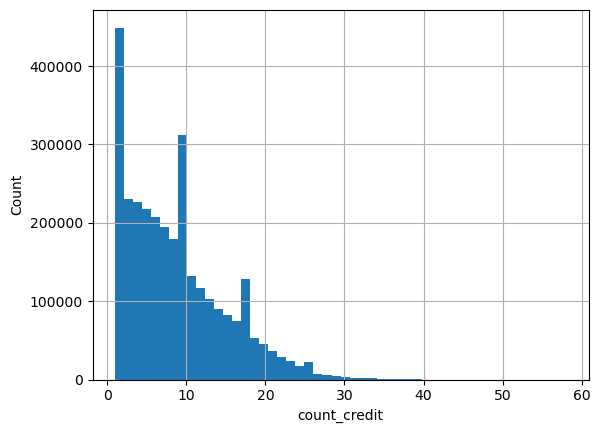

Histogram for bad_pay_count_last


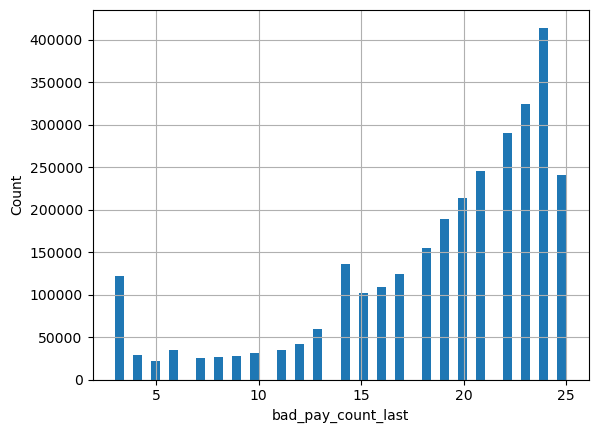

Histogram for paym_status_variance_last


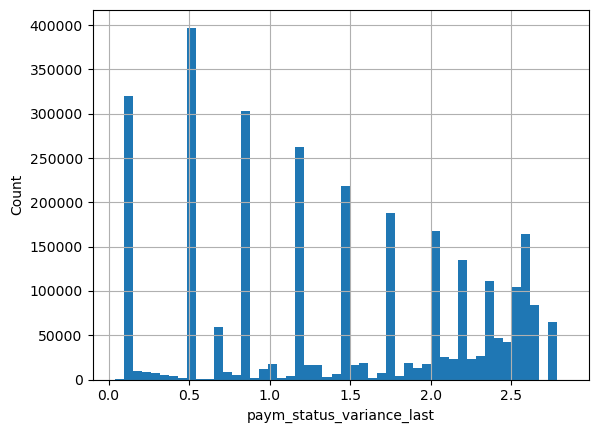

In [31]:
import matplotlib.pyplot as plt

selected_features = ['count_credit', 'bad_pay_count_last', 'paym_status_variance_last']

for col in selected_features:
    if col in final_dataset.columns:
        print(f'Histogram for {col}')
        final_dataset[col].hist(bins=50)
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()


## Model Training
### Experiment 1: Train-test split without new features and aggregation

In [32]:
from sklearn.model_selection import train_test_split
import pandas as pd

columns_to_drop = ['flag', 'id', 'enc_mode_last', 'bad_pay_count_last', 'paym_status_variance_last']

df_last_state = pd.read_parquet('data/processed/df_last_state.parquet')

X_train, X_test, y_train, y_test = train_test_split(
    df_last_state.drop(columns=columns_to_drop),
    df_last_state['flag'],
    test_size=0.20,
    stratify=df_last_state['flag'],
    random_state=42
)

In [33]:
# Train
print(X_train.shape)
X_train.head()

(2400000, 28)


,count_credit,pre_since_opened_last,pre_since_confirmed_last,pre_pterm_last,pre_till_pclose_last,pre_loans_credit_limit_last,pre_loans_next_pay_summ_last,pre_loans_outstanding_last,pre_loans_max_overdue_sum_last,pre_loans_credit_cost_rate_last,...,is_zero_util_last,is_zero_maxover2limit_last,enc_loans_credit_status_last,enc_loans_account_cur_last,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last
2307217,8,9,9,10,10,11,4,5,2,13,...,0,1,2,1,4,0,0,0,0,4
925303,5,7,6,9,1,6,6,3,2,2,...,0,1,2,1,4,0,1,0,3,4
1399565,12,19,5,4,2,4,2,3,2,6,...,1,1,3,1,5,0,0,3,3,4
342697,6,7,9,4,1,6,6,4,2,5,...,0,1,2,1,3,1,0,0,3,4
2814014,30,19,0,3,7,12,2,3,2,6,...,1,1,3,1,5,0,0,3,3,4


In [34]:
# Test
print(X_test.shape)
X_test.head()

(600000, 28)


,count_credit,pre_since_opened_last,pre_since_confirmed_last,pre_pterm_last,pre_till_pclose_last,pre_loans_credit_limit_last,pre_loans_next_pay_summ_last,pre_loans_outstanding_last,pre_loans_max_overdue_sum_last,pre_loans_credit_cost_rate_last,...,is_zero_util_last,is_zero_maxover2limit_last,enc_loans_credit_status_last,enc_loans_account_cur_last,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last
1679350,4,7,5,2,8,11,3,5,2,4,...,0,1,2,1,4,0,0,3,3,4
385353,6,7,9,4,1,14,5,5,2,9,...,0,1,2,1,3,1,0,0,3,4
2137282,10,7,0,9,12,17,2,4,2,3,...,0,1,2,1,5,0,0,3,3,4
896053,13,1,1,0,0,1,2,3,2,4,...,1,1,2,1,3,0,1,3,3,4
2824317,4,12,9,4,1,17,4,2,2,2,...,0,1,2,1,3,1,3,3,3,4


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


model_1 = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_1.fit(X_train, y_train)

y_pred_proba = model_1.predict_proba(X_test)[:, 1]

roc_auc_1 = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc_1:.4f}")

ROC-AUC: 0.6866


**Result:**

ROC-AUC: 0.6866

### Experiment 2

Model with new features, without aggregation

In [36]:
from sklearn.model_selection import train_test_split
import pandas as pd

df_last_state = pd.read_parquet('data/processed/df_last_state.parquet')

X_train, X_test, y_train, y_test = train_test_split(
    df_last_state.drop(columns=['flag', 'id']),
    df_last_state['flag'],
    test_size=0.20,
    stratify=df_last_state['flag'],
    random_state=42
)

In [37]:
# Train
print(X_train.shape)
X_train.head()

(2400000, 31)


,count_credit,pre_since_opened_last,pre_since_confirmed_last,pre_pterm_last,pre_till_pclose_last,pre_loans_credit_limit_last,pre_loans_next_pay_summ_last,pre_loans_outstanding_last,pre_loans_max_overdue_sum_last,pre_loans_credit_cost_rate_last,...,enc_loans_account_cur_last,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last,enc_mode_last,bad_pay_count_last,paym_status_variance_last
2307217,8,9,9,10,10,11,4,5,2,13,...,1,4,0,0,0,0,4,3,15,2.66
925303,5,7,6,9,1,6,6,3,2,2,...,1,4,0,1,0,3,4,3,21,1.75
1399565,12,19,5,4,2,4,2,3,2,6,...,1,5,0,0,3,3,4,3,24,0.50
342697,6,7,9,4,1,6,6,4,2,5,...,1,3,1,0,0,3,4,3,19,2.00
2814014,30,19,0,3,7,12,2,3,2,6,...,1,5,0,0,3,3,4,3,23,0.86


In [38]:
# Test
print(X_test.shape)
X_test.head()

(600000, 31)


,count_credit,pre_since_opened_last,pre_since_confirmed_last,pre_pterm_last,pre_till_pclose_last,pre_loans_credit_limit_last,pre_loans_next_pay_summ_last,pre_loans_outstanding_last,pre_loans_max_overdue_sum_last,pre_loans_credit_cost_rate_last,...,enc_loans_account_cur_last,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last,enc_mode_last,bad_pay_count_last,paym_status_variance_last
1679350,4,7,5,2,8,11,3,5,2,4,...,1,4,0,0,3,3,4,3,20,1.760000
385353,6,7,9,4,1,14,5,5,2,9,...,1,3,1,0,0,3,4,3,19,2.000000
2137282,10,7,0,9,12,17,2,4,2,3,...,1,5,0,0,3,3,4,3,22,1.190000
896053,13,1,1,0,0,1,2,3,2,4,...,1,3,0,1,3,3,4,3,24,0.806667
2824317,4,12,9,4,1,17,4,2,2,2,...,1,3,1,3,3,3,4,3,25,0.110000


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


model_2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_2.fit(X_train, y_train)

y_pred_proba = model_2.predict_proba(X_test)[:, 1]

roc_auc_2 = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc_2:.4f}")

ROC-AUC: 0.6855


**Result:**

ROC-AUC: 0.6855

### Experiment 3

Model with all features

In [40]:
from sklearn.model_selection import train_test_split
import pandas as pd

final_dataset = pd.read_parquet('data/processed/final_dataset.parquet')

X_train, X_test, y_train, y_test = train_test_split(
    final_dataset.drop(columns=['flag', 'id']),
    final_dataset['flag'],
    test_size=0.20,
    stratify=final_dataset['flag'],
    random_state=42
)

In [41]:
# Тренировочный датасет
print(X_train.shape)
X_train.head()

(2400000, 71)


,pre_since_opened_median,pre_since_opened_max,pre_since_confirmed_median,pre_pterm_median,pre_pterm_max,pre_till_pclose_median,pre_till_pclose_max,pre_loans_credit_limit_median,pre_loans_credit_limit_max,pre_loans_next_pay_summ_median,...,enc_loans_account_cur_last,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last,enc_mode_last,bad_pay_count_last,paym_status_variance_last
2307217,4.5,11,9.0,11.0,17,11.5,15,12.5,16,2.0,...,1,4,0,0,0,0,4,3,15,2.66
925303,11.0,17,6.0,9.0,16,6.0,15,6.0,19,4.0,...,1,4,0,1,0,3,4,3,21,1.75
1399565,10.0,19,10.0,4.0,17,3.0,16,7.5,19,2.0,...,1,5,0,0,3,3,4,3,24,0.50
342697,11.0,13,9.5,14.5,17,6.5,16,17.5,19,2.0,...,1,3,1,0,0,3,4,3,19,2.00
2814014,10.0,19,11.0,4.0,17,8.0,16,8.0,16,2.0,...,1,5,0,0,3,3,4,3,23,0.86


In [42]:
# Тестовый датасет
print(X_test.shape)
X_test.head()

(600000, 71)


,pre_since_opened_median,pre_since_opened_max,pre_since_confirmed_median,pre_pterm_median,pre_pterm_max,pre_till_pclose_median,pre_till_pclose_max,pre_loans_credit_limit_median,pre_loans_credit_limit_max,pre_loans_next_pay_summ_median,...,enc_loans_account_cur_last,enc_loans_credit_type_last,pclose_flag_last,enc_paym_0_last,enc_paym_5_last,enc_paym_8_last,enc_paym_11_last,enc_mode_last,bad_pay_count_last,paym_status_variance_last
1679350,9.0,13,7.0,6.0,17,8.0,13,11.0,14,2.5,...,1,4,0,0,3,3,4,3,20,1.760000
385353,5.5,9,6.0,12.5,17,8.0,15,14.0,15,2.0,...,1,3,1,0,0,3,4,3,19,2.000000
2137282,10.0,14,4.0,10.0,16,6.0,13,8.0,17,2.0,...,1,5,0,0,3,3,4,3,22,1.190000
896053,3.0,18,9.0,9.0,15,5.0,13,12.0,18,2.0,...,1,3,0,1,3,3,4,3,24,0.806667
2824317,9.0,12,9.0,7.0,12,5.5,12,15.5,17,4.0,...,1,3,1,3,3,3,4,3,25,0.110000


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


model_3 = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_3.fit(X_train, y_train)

y_pred_proba = model_3.predict_proba(X_test)[:, 1]
roc_auc_3 = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc_3:.4f}")

ROC-AUC: 0.7158


**Result:**

ROC-AUC: 0.7157

After comparing three datasets with different feature sets, I can see that the best result comes from the dataset with new features and aggregation.


In [44]:
# Check feature importance to find weak features
importances = pd.DataFrame({'feature': X_train.columns, 'importance': model_3.feature_importances_}).sort_values(by='importance', ascending=False)
importances[60:].feature.tolist()

['pre_over2limit_max',
 'pre_loans_max_overdue_sum_last',
 'pre_maxover2limit_last',
 'pre_loans_next_pay_summ_last',
 'pre_since_confirmed_last',
 'pre_loans_next_pay_summ_median',
 'is_zero_maxover2limit_min',
 'pre_over2limit_last',
 'pre_loans_max_overdue_sum_median',
 'pclose_flag_last',
 'enc_loans_account_cur_last']

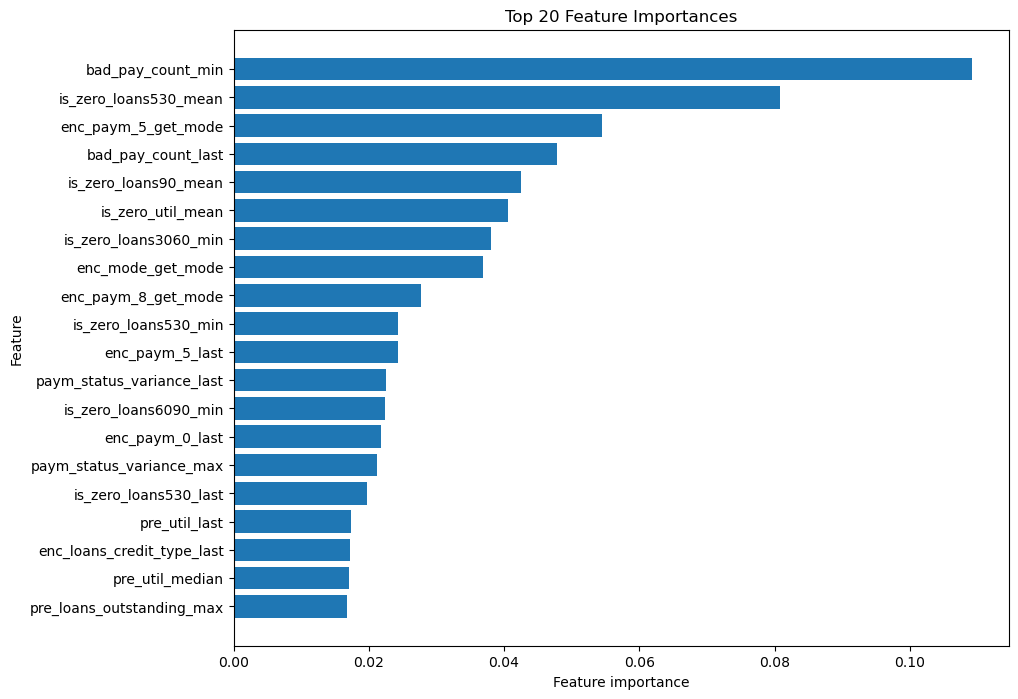

In [45]:
# Importance visualization

import matplotlib.pyplot as plt

top_features = importances.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [46]:
# Remove weak and noisy features

col_to_drop = ['id', 'pre_loans_max_overdue_sum_last', 'pre_since_confirmed_last',
    'pre_over2limit_last', 'pclose_flag_last', 'enc_paym_11_last',
    'bad_pay_count_last', 'enc_paym_8_last', 'is_zero_loans90_last',
    'is_zero_loans6090_last'
]

df_ready = final_dataset.drop(columns=col_to_drop)

# Remove weak and noisy features
df_ready.to_parquet('data/processed/df_ready.parquet', index=False)

### Final Training on Cleaned Dataset

In [47]:
from sklearn.model_selection import train_test_split
import pandas as pd

df_ready = pd.read_parquet('data/processed/df_ready.parquet')

X_train, X_test, y_train, y_test = train_test_split(
    df_ready.drop(columns=['flag']),
    df_ready['flag'],
    test_size=0.20,
    stratify=df_ready['flag'],
    random_state=42
)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


model_4 = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_4.fit(X_train, y_train)

y_pred_proba = model_4.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_pred_proba)

0.7164419806322978

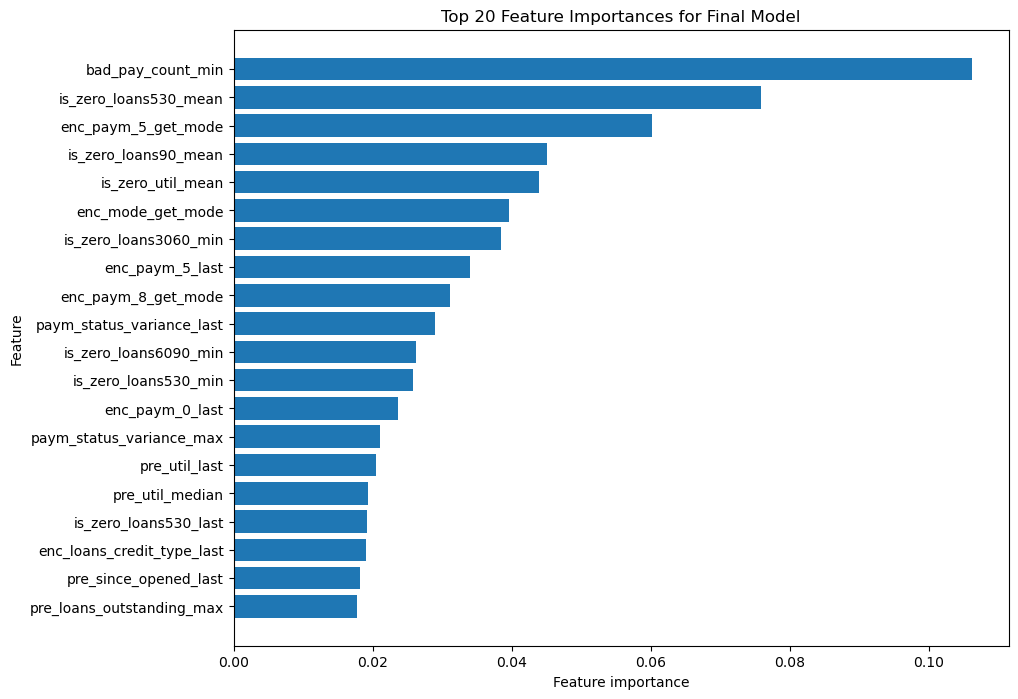

In [49]:
# Feature importance visualization for the final model

import matplotlib.pyplot as plt

importances_2 = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_4.feature_importances_
}).sort_values(by="importance", ascending=False)

top_features = importances_2.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances for Final Model")
plt.gca().invert_yaxis()
plt.show()

### LightGBM Model Training

#### Default LightGBM Model



In [50]:
# Install LightGBM
!pip install lightgbm

In [51]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

lgbm_model_simple = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgbm_model_simple.fit(X_train, y_train)

y_pred_proba_lgbm = lgbm_model_simple.predict_proba(X_test)[:, 1]
roc_auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)

print(f"ROC AUC: {roc_auc_lgbm:.4f}")

[LightGBM] [Info] Number of positive: 85154, number of negative: 2314846
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2234
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC AUC: 0.7422


#### LightGBM Hyperparameter Tuning with Optuna on a Data Sample



In [52]:
from sklearn.model_selection import train_test_split
import pandas as pd

df_ready = pd.read_parquet('data/processed/df_ready.parquet')

chunk = df_ready.sample(n=250000, random_state=42)
X_small = chunk.drop(['flag'], axis=1)
y_small = chunk['flag']

X_train_op, X_val_op, y_train_op, y_val_op = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=42
)

In [53]:
X_train_op

,pre_since_opened_median,pre_since_opened_max,pre_since_confirmed_median,pre_pterm_median,pre_pterm_max,pre_till_pclose_median,pre_till_pclose_max,pre_loans_credit_limit_median,pre_loans_credit_limit_max,pre_loans_next_pay_summ_median,...,pre_maxover2limit_last,is_zero_util_last,is_zero_maxover2limit_last,enc_loans_credit_status_last,enc_loans_account_cur_last,enc_loans_credit_type_last,enc_paym_0_last,enc_paym_5_last,enc_mode_last,paym_status_variance_last
2345927,8.0,16,7.0,4.0,7,4.0,14,13.0,18,2.0,...,17,0,1,2,1,5,0,3,3,0.860000
427962,9.0,19,3.0,4.0,16,7.0,11,2.0,15,2.0,...,17,1,1,3,1,4,0,3,3,1.190000
594203,5.0,9,13.0,9.0,12,6.0,12,5.0,8,3.5,...,17,0,1,2,1,0,0,0,3,2.540000
1254045,9.0,19,9.0,13.0,14,10.0,14,6.0,16,3.0,...,17,0,1,2,1,4,0,3,3,0.500000
2906835,11.0,19,8.0,8.0,17,4.0,15,14.0,15,2.0,...,17,0,1,2,1,3,0,3,3,0.860000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702951,10.5,17,8.0,9.5,17,3.0,11,8.0,17,2.0,...,17,1,1,2,1,3,0,0,3,2.000000
2328164,15.0,18,8.0,6.0,17,7.0,16,9.0,19,2.0,...,17,0,1,2,1,3,1,3,3,0.456667
1668857,9.0,18,7.0,14.5,17,7.5,14,11.0,17,2.0,...,17,0,1,2,1,4,0,3,3,0.860000
1361899,16.0,19,7.0,7.0,16,10.0,16,9.0,19,2.0,...,17,0,1,2,1,4,3,3,3,0.110000


In [54]:
!pip install optuna

In [55]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score


def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 4000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 8, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 100, 400),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 1.0)
    }
    model = lgb.LGBMClassifier(**param, verbosity=-1)
    model.fit(X_train_op, y_train_op)
    preds = model.predict_proba(X_val_op)[:, 1]
    score = roc_auc_score(y_val_op, preds)
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, timeout=3600)

[I 2026-05-06 17:06:40,380] A new study created in memory with name: no-name-8ec03715-5640-4fe9-8906-faa3e7cf23bb
[I 2026-05-06 17:07:24,551] Trial 0 finished with value: 0.6703852215501831 and parameters: {'n_estimators': 3096, 'num_leaves': 67, 'learning_rate': 0.07485648022113435, 'max_depth': 9, 'min_child_samples': 227, 'subsample': 0.5800958821760585, 'colsample_bytree': 0.9528866265787597, 'reg_lambda': 0.42960183680407554, 'reg_alpha': 0.7021819541049614}. Best is trial 0 with value: 0.6703852215501831.
[I 2026-05-06 17:08:22,137] Trial 1 finished with value: 0.7045421215948476 and parameters: {'n_estimators': 2526, 'num_leaves': 84, 'learning_rate': 0.025131173153984866, 'max_depth': 18, 'min_child_samples': 389, 'subsample': 0.8155115897740912, 'colsample_bytree': 0.5624321638421377, 'reg_lambda': 0.8098046217758706, 'reg_alpha': 0.8909480640749023}. Best is trial 1 with value: 0.7045421215948476.
[I 2026-05-06 17:08:54,379] Trial 2 finished with value: 0.7054401095204632 and

In [56]:
print("Best parameters:", study.best_params)
print("Best ROC-AUC:", study.best_value)

Best parameters: {'n_estimators': 1762, 'num_leaves': 25, 'learning_rate': 0.010207204718943423, 'max_depth': 14, 'min_child_samples': 392, 'subsample': 0.9655967506494911, 'colsample_bytree': 0.5046126908532006, 'reg_lambda': 0.7647985478158168, 'reg_alpha': 0.9425564000578067}
Best ROC-AUC: 0.7335549897207104


#### Final LightGBM Model with Tuned Parameters

In [57]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

lgbm_model_final = lgb.LGBMClassifier(
    n_estimators=3222,
    learning_rate= 0.015,
    max_depth=14,
    num_leaves=66,
    min_child_samples= 330,
    subsample=0.6,
    colsample_bytree=0.5,
    reg_lambda=0.3,
    reg_alpha=7,
    scale_pos_weight= 1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


lgbm_model_final.fit(X_train, y_train)

y_pred_proba_lgbm = lgbm_model_final.predict_proba(X_test)[:, 1]
roc_auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)

print(f"\n Final result LightGBM")
print(f"ROC AUC: {roc_auc_lgbm:.4f}")


 Final result LightGBM
ROC AUC: 0.7501


## ROC Curve

The ROC curve shows how well the model separates class 0 and class 1 at different thresholds.

A curve closer to the top-left corner means better model quality.

Text(0, 0.5, 'tpr')

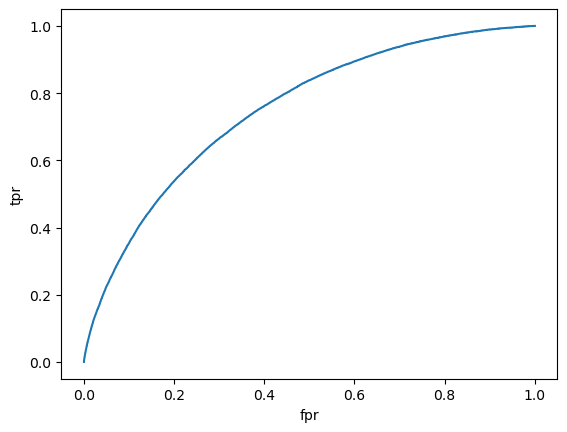

In [58]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lgbm)
plt.plot(fpr, tpr, '-')
plt.xlabel('fpr')
plt.ylabel('tpr')

## Pipeline

This notebook shows the full project logic: data processing, feature engineering, aggregation, model training, and evaluation.

Because the dataset is large, I process the data in chunks to reduce memory usage.

The cleaner production-style code is moved to Python scripts in the `src/` folder.

### Feature Engineering Class

This class creates new payment history features and keeps only useful columns.

In [59]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
from pandas.api.types import is_integer_dtype, is_float_dtype
import gc


class CreditFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        print('Step 1: CreditFeatureEngineer')

        paym_cols = [c for c in X.columns if c.startswith('enc_paym_')]

        X['enc_mode'] = X[paym_cols].mode(axis=1, dropna=True).iloc[:, 0].fillna(-1).astype('Int8')
        gc.collect()
        X['bad_pay_count'] = (X[paym_cols] > 0).sum(axis=1).astype('Int8')
        gc.collect()
        X['paym_status_variance'] = X[paym_cols].var(axis=1).fillna(0).astype('float32')

        stayed_columns = [
            'id', 'rn', 'pre_since_opened', 'pre_since_confirmed', 'pre_pterm',
            'pre_till_pclose', 'pre_loans_credit_limit', 'pre_loans_next_pay_summ',
            'pre_loans_outstanding', 'pre_loans_max_overdue_sum',
            'pre_loans_credit_cost_rate', 'is_zero_loans5', 'is_zero_loans530',
            'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90', 'pre_util',
            'pre_over2limit', 'pre_maxover2limit', 'is_zero_util', 'is_zero_maxover2limit',
            'enc_loans_credit_status', 'enc_loans_account_cur',
            'enc_loans_credit_type', 'pclose_flag', 'enc_paym_0', 'enc_paym_5',
            'enc_paym_8', 'enc_paym_11', 'enc_mode', 'bad_pay_count',
            'paym_status_variance'
        ]

        for c in X.select_dtypes(include=['int64', 'int32']).columns:
          X[c] = pd.to_numeric(X[c], downcast='integer')

        gc.collect()

        return X[stayed_columns]

### Feature Engineering Class

This class creates new payment history features and keeps only useful columns.

In [60]:
class DataAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, agg_dict):
        self.agg_dict = agg_dict

    def fit(self, X, y=None):
        return self

    @staticmethod
    def get_mode(x):
        return x.mode().iloc[0] if not x.mode().empty else None

    def transform(self, X):
        print('Step 2: DataAggregator')

        group = X.groupby('id').agg(self.agg_dict)
        group.columns = [f'{c[0]}_{c[1]}' if isinstance(c, tuple) else c for c in group.columns]

        last_state = X.sort_values(['id', 'rn']).drop_duplicates('id', keep='last')

        last_state.columns = [c if c == 'id' else f'{c}_last' for c in last_state.columns]

        final_df = pd.merge(group.reset_index(), last_state, on='id', how='left')

        for c in final_df.select_dtypes(include=['float64']).columns:
            final_df[c] = final_df[c].astype('float32')

        gc.collect()

        return final_df

### Column Dropper Class

This class removes weak or unnecessary columns before model training.

In [61]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, final_df, y=None):
        return self

    def transform(self, final_df):
        print('Step 3: ColumnDropper')

        return final_df.drop(columns=self.columns_to_drop)

### Preprocessing Pipeline without Model

This pipeline is used only for data preprocessing.  
I use it before model training because the full raw dataset is too large to process and train at the same time.


In [62]:
from sklearn.pipeline import Pipeline
import lightgbm as lgb

col_to_drop = ['id', 'pre_loans_max_overdue_sum_last', 'pre_since_confirmed_last',
    'pre_over2limit_last', 'pclose_flag_last', 'enc_paym_11_last',
    'bad_pay_count_last', 'enc_paym_8_last', 'is_zero_loans90_last',
    'is_zero_loans6090_last'
]

agg = {
    'pre_since_opened': ['median', 'max'],
    'pre_since_confirmed': 'median',
    'pre_pterm': ['median', 'max'],
    'pre_till_pclose': ['median', 'max'],
    'pre_loans_credit_limit': ['median', 'max'],
    'pre_loans_next_pay_summ':'median',
    'pre_loans_outstanding': ['median', 'max'],
    'pre_loans_max_overdue_sum': 'median',
    'pre_loans_credit_cost_rate': ['median', 'max'],
    'is_zero_loans5': ['min', 'mean'],
    'is_zero_loans530': ['min', 'mean'],
    'is_zero_loans3060': 'min',
    'is_zero_loans6090': 'min',
    'is_zero_loans90': 'mean',
    'pre_util': ['median', 'max'],
    'pre_over2limit': 'max',
    'pre_maxover2limit': 'median',
    'is_zero_util': 'mean',
    'is_zero_maxover2limit': ['min', 'mean'],
    'enc_loans_credit_status': DataAggregator.get_mode,
    'enc_loans_credit_type': DataAggregator.get_mode,
    'pclose_flag': 'mean',
    'enc_paym_5': DataAggregator.get_mode,
    'enc_mode': DataAggregator.get_mode,
    'enc_paym_8': DataAggregator.get_mode,
    'enc_paym_11': DataAggregator.get_mode,
    'bad_pay_count': ['sum', 'min', 'max'],
    'paym_status_variance': 'max'
}

main_pipeline = Pipeline([
    ('engineer', CreditFeatureEngineer()),
    ('aggregator', DataAggregator(agg_dict=agg)),
    ('dropper', ColumnDropper(col_to_drop))
])

Because the dataset is large, I process raw data in chunks.

For each chunk, I apply the preprocessing pipeline and then add the processed chunk to one dataset.

In [ ]:
chunk_merged = pd.DataFrame()

for i in range(12):
  print(f'Processing chunk {i} ...')
  chunk = pd.read_parquet(f'data/raw/train_data/train_data_{i}.pq')

  chunk_prepared = main_pipeline.fit_transform(chunk)
  chunk_merged = pd.concat([chunk_merged, chunk_prepared], ignore_index = True)

  del chunk, chunk_prepared
  gc.collect()

df = chunk_merged.sort_values(by='id')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Обрабатывается чанк 0 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 1 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 2 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 3 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 4 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 5 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 6 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 7 ...
Step 1: CreditFeatureEngineer
Step 2: DataAggregator
Step 3: ColumnDropper
Обрабатывается чанк 8 ...
Step 1: CreditFeatureEngineer
Step 2:

In [ ]:
df.to_parquet('data/processed/final_df.pq')

In [ ]:
df = pd.read_parquet('data/processed/final_df.pq')
y_path = 'data/raw/train_target.csv'
X = df.drop(columns=['id'])
y = pd.read_csv(y_path).sort_values(by='id').drop(columns=['id'])

### Train Final Model

After preprocessing all chunks, I train the final model on the prepared dataset.

In [ ]:
lgbm_final = lgb.LGBMClassifier(
    n_estimators=3222,
    learning_rate=0.015,
    max_depth=14,
    num_leaves=66,
    min_child_samples=330,
    subsample=0.6,
    colsample_bytree=0.5,
    reg_lambda=0.3,
    reg_alpha=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgbm_final.fit(X, y)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 106442, number of negative: 2893558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.768123 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2308
[LightGBM] [Info] Number of data points in the train set: 3000000, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.5,
               learning_rate=0.015, max_depth=14, min_child_samples=330,
               n_estimators=3222, n_jobs=-1, num_leaves=66, random_state=42,
               reg_alpha=7, reg_lambda=0.3, subsample=0.6)

### Final Pipeline with Trained Model

After training the model, I add it to the pipeline and save the final pipeline with joblib.
This saved pipeline can be used later for predictions.

In [ ]:
from sklearn.pipeline import Pipeline
import lightgbm as lgb

col_to_drop = ['id', 'pre_loans_max_overdue_sum_last', 'pre_since_confirmed_last',
    'pre_over2limit_last', 'pclose_flag_last', 'enc_paym_11_last',
    'bad_pay_count_last', 'enc_paym_8_last', 'is_zero_loans90_last',
    'is_zero_loans6090_last'
]

agg = {
    'pre_since_opened': ['median', 'max'],
    'pre_since_confirmed': 'median',
    'pre_pterm': ['median', 'max'],
    'pre_till_pclose': ['median', 'max'],
    'pre_loans_credit_limit': ['median', 'max'],
    'pre_loans_next_pay_summ':'median',
    'pre_loans_outstanding': ['median', 'max'],
    'pre_loans_max_overdue_sum': 'median',
    'pre_loans_credit_cost_rate': ['median', 'max'],
    'is_zero_loans5': ['min', 'mean'],
    'is_zero_loans530': ['min', 'mean'],
    'is_zero_loans3060': 'min',
    'is_zero_loans6090': 'min',
    'is_zero_loans90': 'mean',
    'pre_util': ['median', 'max'],
    'pre_over2limit': 'max',
    'pre_maxover2limit': 'median',
    'is_zero_util': 'mean',
    'is_zero_maxover2limit': ['min', 'mean'],
    'enc_loans_credit_status': DataAggregator.get_mode,
    'enc_loans_credit_type': DataAggregator.get_mode,
    'pclose_flag': 'mean',
    'enc_paym_5': DataAggregator.get_mode,
    'enc_mode': DataAggregator.get_mode,
    'enc_paym_8': DataAggregator.get_mode,
    'enc_paym_11': DataAggregator.get_mode,
    'bad_pay_count': ['sum', 'min', 'max'],
    'paym_status_variance': 'max'
}

main_pipeline = Pipeline([
    ('engineer', CreditFeatureEngineer()),
    ('aggregator', DataAggregator(agg_dict=agg)),
    ('dropper', ColumnDropper(col_to_drop)),
    ('model', lgbm_final)
])

In [ ]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(main_pipeline, "models/pipeline.pkl")

['/content/drive/MyDrive/FinalProject/pipeline.pkl']